In [13]:
import deepchem as dc
from rdkit import Chem

In [14]:
smiles = ['C1CCCCC1', 'O1CCOCC1'] # cyclohexane and dioxane
mols = [Chem.MolFromSmiles(smile) for smile in smiles]
feat = dc.feat.CircularFingerprint(size=1024)
arr = feat.featurize(mols)

[19:47:54] DEPRECATION WARNING: please use MorganGenerator
[19:47:54] DEPRECATION WARNING: please use MorganGenerator


In [15]:
feat = dc.feat.RDKitDescriptors()
arr = feat.featurize(mols)

In [16]:
tasks, datasets, transformers = dc.molnet.load_delaney(featurizer='GraphConv')
train_dataset, valid_dataset, test_dataset = datasets

In [17]:
from deepchem.models.graph_models import GraphConvModel

In [18]:
model = GraphConvModel(n_tasks=1, mode='regression', dropout=0.2)
model.fit(train_dataset, nb_epoch=1) # nb_epoch=100 recommended

1.1347880363464355

In [19]:
metric = dc.metrics.Metric(dc.metrics.pearson_r2_score)
print(model.evaluate(train_dataset, [metric], transformers))
print(model.evaluate(test_dataset, [metric], transformers))

{'pearson_r2_score': 0.23410062460142742}
{'pearson_r2_score': 0.20962380880385412}


In [20]:
smiles = ['COC(C)(C)CCCC(C)CC=CC(C)=CC(=O)OC(C)C',
          'CCOC(=O)CC',
          'CSc1nc(NC(C)C)nc(NC(C)C)n1',
          'CC(C#C)N(C)C(=O)Nc1ccc(Cl)cc1',
          'Cc1cc2ccccc2cc1C']

In [21]:
from rdkit import Chem
mols = [Chem.MolFromSmiles(s) for s in smiles]
featurizer = dc.feat.ConvMolFeaturizer()
x = featurizer.featurize(mols)

[19:48:03] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[19:48:03] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[19:48:03] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[19:48:03] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[19:48:03] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[19:48:03] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[19:48:03] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[19:48:03] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[19:48:03] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[19:48:03] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[19:48:03] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[19:48:03] DEPRECATIO

In [22]:
predicted_solubility = model.predict_on_batch(x)

In [23]:
from rdkit import Chem
from rdkit.Chem.Draw import MolsToGridImage

smiles_list = ["CCCCC","CCOCC","CCNCC","CCSCC"]
mol_list = [Chem.MolFromSmiles(x) for x in smiles_list]

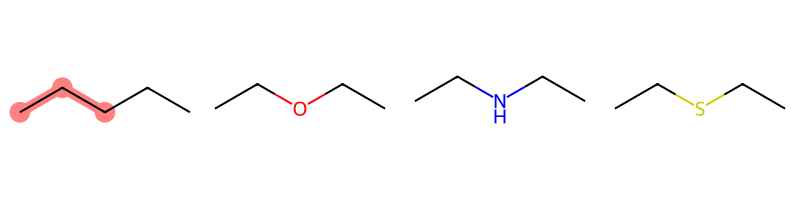

In [24]:
query = Chem.MolFromSmarts("CCC")
match_list = [mol.GetSubstructMatch(query) for mol in
mol_list]
MolsToGridImage(mols=mol_list, molsPerRow=4,
highlightAtomLists=match_list)

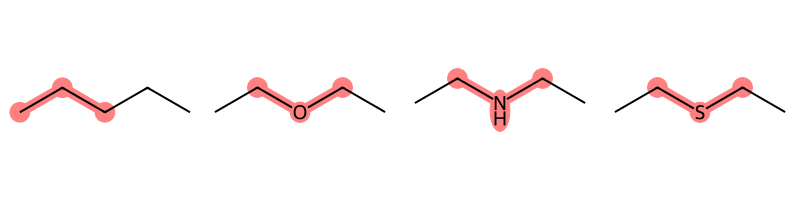

In [25]:
query = Chem.MolFromSmarts("C*C")
match_list = [mol.GetSubstructMatch(query) for mol in
mol_list]
MolsToGridImage(mols=mol_list, molsPerRow=4,
highlightAtomLists=match_list)

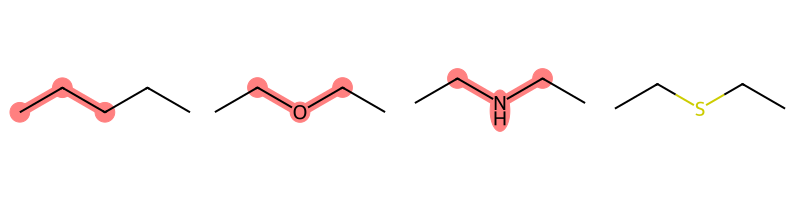

In [26]:
query = Chem.MolFromSmarts("C[C,N,O]C")
match_list = [mol.GetSubstructMatch(query) for mol in
mol_list]
MolsToGridImage(mols=mol_list, molsPerRow=4,
highlightAtomLists=match_list)